## Classificando os dados

In [1]:
import pandas as pd

In [2]:
dados = pd.read_csv('/content/drive/MyDrive/Dados_Csv/emp_automovel.csv')

In [3]:
dados

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.000000,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.000000,0
1,9000.000000,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.000000,0
2,15750.000000,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.000000,0
3,9000.000000,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.000000,0
4,7650.000000,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
54020,16855.246324,675.000000,12.157324,1,2.0,0.501213,0.180635,0.513171,0.082500,0.000000,1
54021,11250.000000,675.000000,14.000000,0,3.0,0.409620,0.606002,0.513171,0.117428,466.000000,1
54022,13500.000000,900.000000,64.000000,0,2.0,0.162632,0.525412,0.513171,0.117428,962.106056,1
54023,11250.000000,2371.500000,12.157324,0,3.0,0.501213,0.664027,0.513171,0.117428,482.000000,1


In [4]:
dados['inadimplente'].value_counts()

,count
inadimplente,
0,49309
1,4716


In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54025 entries, 0 to 54024
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      54025 non-null  float64
 1   anuidade_emprestimo  54025 non-null  float64
 2   anos_casa_propria    54025 non-null  float64
 3   telefone_trab        54025 non-null  int64  
 4   avaliacao_cidade     54025 non-null  float64
 5   score_1              54025 non-null  float64
 6   score_2              54025 non-null  float64
 7   score_3              54025 non-null  float64
 8   score_social         54025 non-null  float64
 9   troca_telefone       54025 non-null  float64
 10  inadimplente         54025 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 4.5 MB


### Criando um modelo inicial

In [6]:
x = dados.drop(columns = 'inadimplente')
y = dados['inadimplente']

In [7]:
from sklearn.tree import DecisionTreeClassifier

In [8]:
modelo = DecisionTreeClassifier()
modelo.fit(x,y)
modelo.score(x,y)

1.0

In [9]:
print(f'Acurácia: {modelo.score(x, y)}')

Acurácia: 1.0


### Validando o modelo

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x, x_teste, y, y_teste = train_test_split(x, y, test_size = 0.15, stratify = y, random_state = 5)
x_treino, x_val, y_treino, y_val = train_test_split(x, y, stratify = y, random_state = 5)

In [12]:
modelo = DecisionTreeClassifier()
modelo.fit(x_treino, y_treino)
print(f'Acurácia de treino: {modelo.score(x_treino, y_treino)}')
print(f'Acurácia de validação: {modelo.score(x_val, y_val)}')

Acurácia de treino: 1.0
Acurácia de validação: 0.846441947565543


In [13]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_treino, y_treino)
print(f'Acurácia de treino: {modelo.score(x_treino, y_treino)}')
print(f'Acurácia de validação: {modelo.score(x_val, y_val)}')

Acurácia de treino: 0.9206445993031359
Acurácia de validação: 0.9059315390645414


### Avaliando o modelo

In [14]:
from sklearn.metrics import confusion_matrix

In [15]:
y_previsto = modelo.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto)
matriz_confusao

array([[10356,   123],
       [  957,    45]])

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

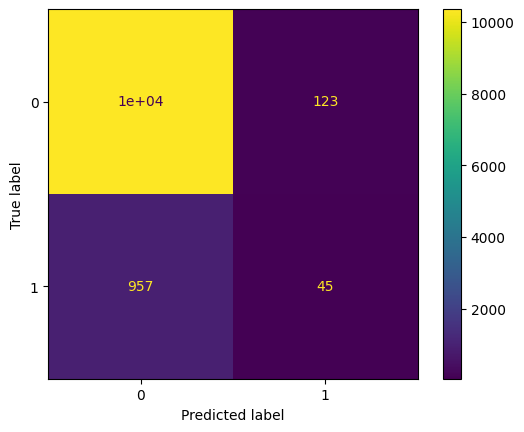

In [17]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao)
visualizacao.plot();

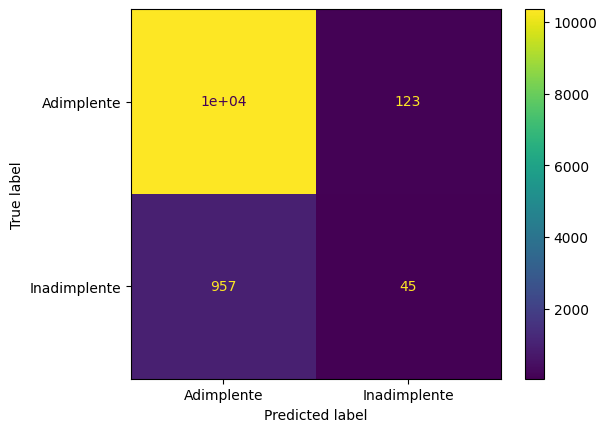

In [18]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao, display_labels=['Adimplente', 'Inadimplente'])
visualizacao.plot();

In [19]:
from sklearn.metrics import classification_report

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
modelo_rf = RandomForestClassifier(max_depth=5)
modelo_rf.fit(x_treino, y_treino)
print(f'Acurácia de treino: {modelo_rf.score(x_treino, y_treino)}')
print(f'Acurácia de validação: {modelo_rf.score(x_val, y_val)}')

Acurácia de treino: 0.9127177700348432
Acurácia de validação: 0.9127253723543245


In [22]:
y_previsto_2 = modelo_rf.predict(x_val)
matriz_confusao = confusion_matrix(y_val, y_previsto_2)
matriz_confusao

array([[10479,     0],
       [ 1002,     0]])

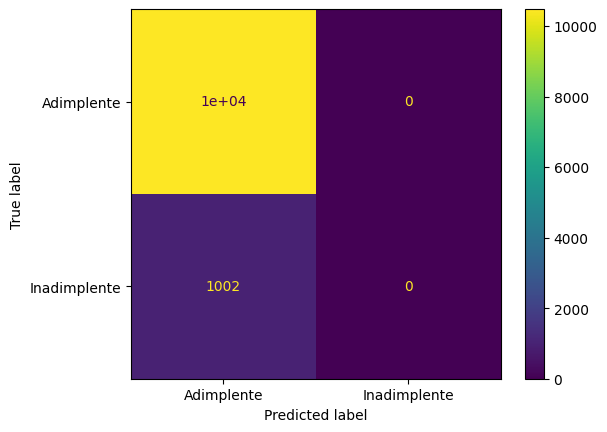

In [23]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao, display_labels=['Adimplente', 'Inadimplente'])
visualizacao.plot();

## Métricas de Avaliação

### Acurácia, Precisão e Recall

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [25]:
print(f'Acurácia: {accuracy_score(y_val, y_previsto)}')

Acurácia: 0.9059315390645414


In [26]:
print(f'Precisão: {precision_score(y_val, y_previsto)}')
print(f'Recall: {recall_score(y_val, y_previsto)}')

Precisão: 0.26785714285714285
Recall: 0.04491017964071856


In [27]:
from sklearn.metrics import f1_score

In [28]:
print(f'F1-score: {f1_score(y_val, y_previsto)}')

F1-score: 0.07692307692307693


### Curva de ROC

In [29]:
from sklearn.metrics import RocCurveDisplay

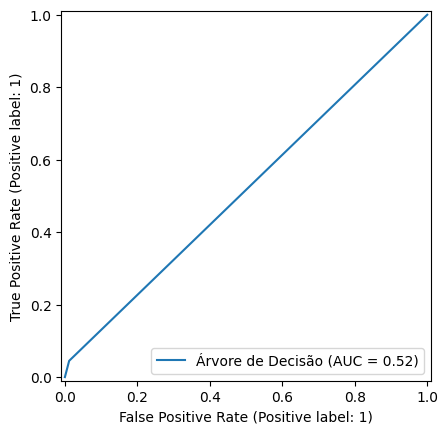

In [30]:
RocCurveDisplay.from_predictions(y_val, y_previsto, name='Árvore de Decisão');

In [31]:
from sklearn.metrics import roc_auc_score

In [32]:
print(f'AUC: {roc_auc_score(y_val, y_previsto)}')

AUC: 0.5165862092019796


### Curva de precisão x Recall

In [33]:
from sklearn.metrics import PrecisionRecallDisplay

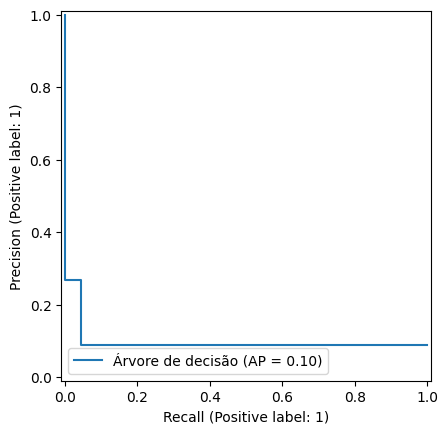

In [34]:
PrecisionRecallDisplay.from_predictions(y_val, y_previsto, name = 'Árvore de decisão');

In [35]:
from sklearn.metrics import average_precision_score

In [36]:
print(f'AP: {average_precision_score(y_val, y_previsto)}')

AP: 0.09538462084379526


## Validação Cruzada

### Usando KFold

In [37]:
from sklearn.model_selection import KFold, cross_validate

In [38]:
modelo = DecisionTreeClassifier(max_depth=10)
kf = KFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultado = cross_validate(modelo, x, y, cv = kf)
cv_resultado

{'fit_time': array([0.35852623, 0.34546304, 0.36238527, 0.34259605, 0.34206605]),
 'score_time': array([0.00474524, 0.00553346, 0.00515199, 0.00461864, 0.00499535]),
 'test_score': array([0.91311922, 0.90766551, 0.90766551, 0.9135453 , 0.89917247])}

In [39]:
cv_resultado['test_score']

array([0.91311922, 0.90766551, 0.90766551, 0.9135453 , 0.89917247])

In [40]:
media = cv_resultado['test_score'].mean()
desvio_padrao = cv_resultado['test_score'].std()
print(f'Intervalo de confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]')

Intervalo de confiança: [0.897847730801504, 0.918619467838909]


In [41]:
def intervalo_conf(resultados):
    media = resultados['test_score'].mean()
    desvio_padrao = resultados['test_score'].std()
    print(f'Intervalo de confiança: [{media - 2*desvio_padrao}, {min(media + 2*desvio_padrao, 1)}]')

In [42]:
modelo = DecisionTreeClassifier(max_depth = 10)
kf = KFold(n_splits = 5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(modelo, x, y, cv = kf, scoring = 'recall')
cv_resultados

{'fit_time': array([0.38240504, 0.35108805, 0.35621095, 0.3514204 , 0.24812245]),
 'score_time': array([0.00808859, 0.00828624, 0.009799  , 0.00590873, 0.00582695]),
 'test_score': array([0.02642008, 0.0210396 , 0.0196802 , 0.01436031, 0.02427746])}

In [43]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.01286930424208624, 0.02944175575228479]


### Estratificando os dados

In [44]:
dados['inadimplente'].value_counts(normalize = True)

,proportion
inadimplente,
0,0.912707
1,0.087293


In [45]:
from sklearn.model_selection import StratifiedKFold

In [46]:
modelo = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultado = cross_validate(modelo, x, y, cv = skf, scoring= 'recall')
cv_resultado

{'fit_time': array([0.25480294, 0.25032973, 0.25193214, 0.24717665, 0.24815965]),
 'score_time': array([0.00643492, 0.00900364, 0.00577211, 0.00581837, 0.006006  ]),
 'test_score': array([0.03491272, 0.03121099, 0.02743142, 0.02493766, 0.0286783 ])}

In [47]:
intervalo_conf(cv_resultado)

Intervalo de confiança: [0.022624075314277268, 0.03624435909283852]


## Balanceamento de dados

### Oversampling

In [48]:
from imblearn.over_sampling import SMOTE

In [49]:
oversample = SMOTE()
x_balanceado, y_balanceado = oversample.fit_resample(x,y)

In [50]:
y_balanceado.value_counts(normalize=True)

,proportion
inadimplente,
0,0.5
1,0.5


In [51]:
modelo = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultado = cross_validate(modelo, x_balanceado, y_balanceado, cv = skf, scoring= 'recall')
cv_resultado

{'fit_time': array([0.59426618, 0.57100463, 0.57525921, 0.57013464, 0.57213283]),
 'score_time': array([0.00736713, 0.00792527, 0.00719023, 0.00726485, 0.00726962]),
 'test_score': array([0.72154617, 0.73180625, 0.73040678, 0.73720625, 0.76807445])}

In [52]:
intervalo_conf(cv_resultado)

Intervalo de confiança: [0.7059123235617822, 0.769703633821832]


### Pipeline de validação

In [53]:
from imblearn.pipeline import Pipeline as ambpipeline

In [54]:
modelo = DecisionTreeClassifier(max_depth=10)
pipeline = ambpipeline([('oversample', SMOTE()), ('arvore', modelo)])

In [55]:
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultado = cross_validate(pipeline, x, y, cv = skf, scoring= 'recall')

In [57]:
intervalo_conf(cv_resultado)

Intervalo de confiança: [0.212619917750327, 0.3241623463148534]


### Undersampling

In [58]:
from imblearn.under_sampling import NearMiss

In [61]:
modelo = DecisionTreeClassifier(max_depth=10)
pipeline = ambpipeline([('undersampling', NearMiss(version = 3)), ('arvore', modelo)])
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultado = cross_validate(pipeline, x, y, cv = skf, scoring= 'recall')

In [62]:
intervalo_conf(cv_resultado)

Intervalo de confiança: [0.624248642857586, 0.7002540828499928]


### Testando o modelo

              precision    recall  f1-score   support

           0       0.94      0.48      0.64      7397
           1       0.11      0.70      0.20       707

    accuracy                           0.50      8104
   macro avg       0.53      0.59      0.42      8104
weighted avg       0.87      0.50      0.60      8104



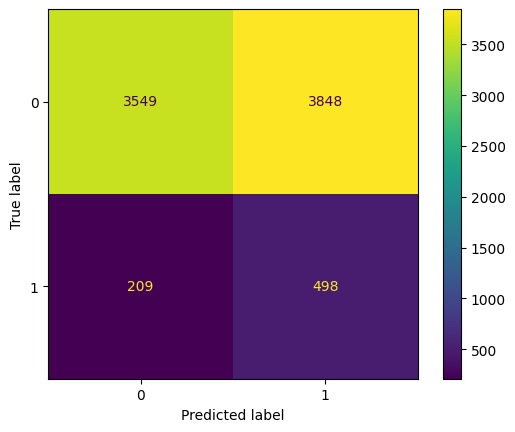

In [64]:
undersampple = NearMiss(version = 3)
x_balanceado, y_balanceado = undersampple.fit_resample(x,y)

modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_balanceado, y_balanceado)
y_previsto = modelo.predict(x_teste)

print(classification_report(y_teste, y_previsto))
ConfusionMatrixDisplay.from_predictions(y_teste, y_previsto);